In [1]:
import geopandas as gpd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.colors
import matplotlib.colorbar
import pandas as pd
import numpy as np
from mapclassify import NaturalBreaks
from matplotlib.lines import Line2D
from matplotlib.markers import MarkerStyle

In [2]:
munis = [218, 126, 148]
colors = ["darkgreen", "darkmagenta", "navy"]

rotated_x2 = MarkerStyle('x', fillstyle='none')
rotated_x2._transform.rotate_deg(45)
marker_styles = ["x", "o", rotated_x2]

tol = 1e-14
days = 21
N = 355
t_end = 504

In [3]:
df_Gem = pd.read_csv('data/Gem_inwoners_totaal_2019.csv', delimiter=',', encoding='latin-1')
UniLocs = np.unique(df_Gem.Gemeentenaam)
UniIDs = [list(df_Gem.Gemeentecode[df_Gem.Gemeentenaam == i])[0] for i in UniLocs]
muni_names = [UniLocs[i] for i in munis]
print(muni_names)

['Oldambt', 'Heemstede', 'Hoorn']


In [4]:
DF_Demo = pd.read_csv('data/DemographicMatrix.csv', delimiter=',')
DemoIDs = np.array(DF_Demo['Unnamed: 0'])
DemoMat_unsorted = np.array(DF_Demo[DF_Demo.keys()[1:]])
DemoMat_sorted = []
for ID in UniIDs:
    code = ID[2:]
    if len(DemoMat_unsorted[DemoIDs == int(code)]) == 0:
        take = DemoMat_unsorted[0]
    else:
        take = DemoMat_unsorted[DemoIDs == int(code)][0]
    DemoMat_sorted.append(take)
DemoMat = (np.array(DemoMat_sorted) / 100).astype(int)
gemeentepop = np.array([np.sum(DemoMat[i]) for i in range(len(UniLocs))])

In [5]:
# infected_seeds.npy contains the 3 needed seed-municipality slices from the full simulation
# array, shape (3, 504, 355) in the order munis = [218, 126, 148]
infected_seeds = np.load('data/infected_seeds.npy')

series_data2 = []
for i in range(len(munis)):
    data = infected_seeds[i, :, :].sum(axis=1)[:t_end:24]
    series_data2.append((max(data), data, muni_names[i], colors[i], marker_styles[i]))
series_data2.sort(key=lambda x: x[0], reverse=True)
series_data2_sorted = series_data2
sorted_muni_order = {entry[2]: i for i, entry in enumerate(series_data2)}

In [6]:
run_data = []
for muni in munis:
    rundatai = [np.load(f"data/run_data/gamma_run_muni={muni}_muni={j}.npy") for j in range(71)]
    run_data.append(rundatai)

series_data1 = []
errs = []
for idx in range(len(munis)):
    data_all = run_data[idx]
    entropys = []
    for run in range(71):
        data = data_all[run][::24, :]
        entropy = []
        for day in range(days):
            daysum = data[day, :].sum()
            entropy_day = 0.0
            for mun in range(N):
                if data[day, mun] > tol:
                    p = data[day, mun] / daysum
                    entropy_day -= (p * np.log(p)) / np.log(N)
            entropy.append(entropy_day)
        entropys.append(entropy)
    mean_entropy = np.mean(entropys, axis=0)
    std_entropy = np.std(entropys, axis=0)
    errs.append(std_entropy)
    series_data1.append((np.max(mean_entropy), mean_entropy, muni_names[idx], colors[idx], marker_styles[idx]))

series_data1_sorted = sorted(series_data1, key=lambda x: sorted_muni_order[x[2]])

In [7]:
def create_spatial_7plots3_linear(data_per_municipality, max_legend_val, title, legend_label,
                                  print_foi_sums=False, target_municipality=None, k=5,
                                  cb_width=0.6, bounds=None, axobj=None, axidx=None, fig=None):
    mapdf = gpd.read_file('data/shapefile/gemeente_2019_v3.shp')
    mapdf = mapdf[mapdf["H2O"] == "NEE"]
    mapdf.sort_values("GM_NAAM", inplace=True)
    mapdf = mapdf.reset_index(drop=True)

    max_time = data_per_municipality.shape[0]
    if max_legend_val is None:
        max_legend_val = np.max(np.max(data_per_municipality[max_time - 1]))
    min_legend_val = np.min(data_per_municipality[max_time - 1])

    cmap = plt.get_cmap('YlOrBr')
    cmaplist = [cmap(i) for i in range(cmap.N)]
    cmaplist[0] = (.5, .5, .5, 0.1)
    cmap = matplotlib.colors.LinearSegmentedColormap.from_list('YlOrBr', cmaplist, cmap.N)

    if bounds is None:
        data_bounds = data_per_municipality[21 * 24 - 1]
        nb = NaturalBreaks(data_bounds[data_bounds > 1], k=k)
        bounds = [0, 1] + nb.bins.tolist()
    norm = matplotlib.colors.BoundaryNorm(bounds, cmap.N)

    for day in range(3):
        day_num = [7, 12, 17][day]
        mapdf.insert(0, 'DAY_' + str(day_num), data_per_municipality[day_num * 24 - 1])
        if print_foi_sums:
            print('Day ' + str(day_num) + ': ' + str(np.sum(data_per_municipality[day_num * 24 - 1])))
        mapdf.plot(ax=axobj[axidx[day]], column='DAY_' + str(day_num),
                   cmap=cmap, norm=norm, edgecolor='black', linewidth=0.25)
        axobj[axidx[day]].set_title('Day ' + str(day_num))
        axobj[axidx[day]].axis('off')
        if target_municipality is not None:
            mapdf[mapdf['GM_NAAM'] == target_municipality].plot(
                ax=axobj[axidx[day]],
                edgecolor='red',
                linewidth=1,
                facecolor='none'
            )

    return bounds, norm

c:\Users\0915564\AppData\Local\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


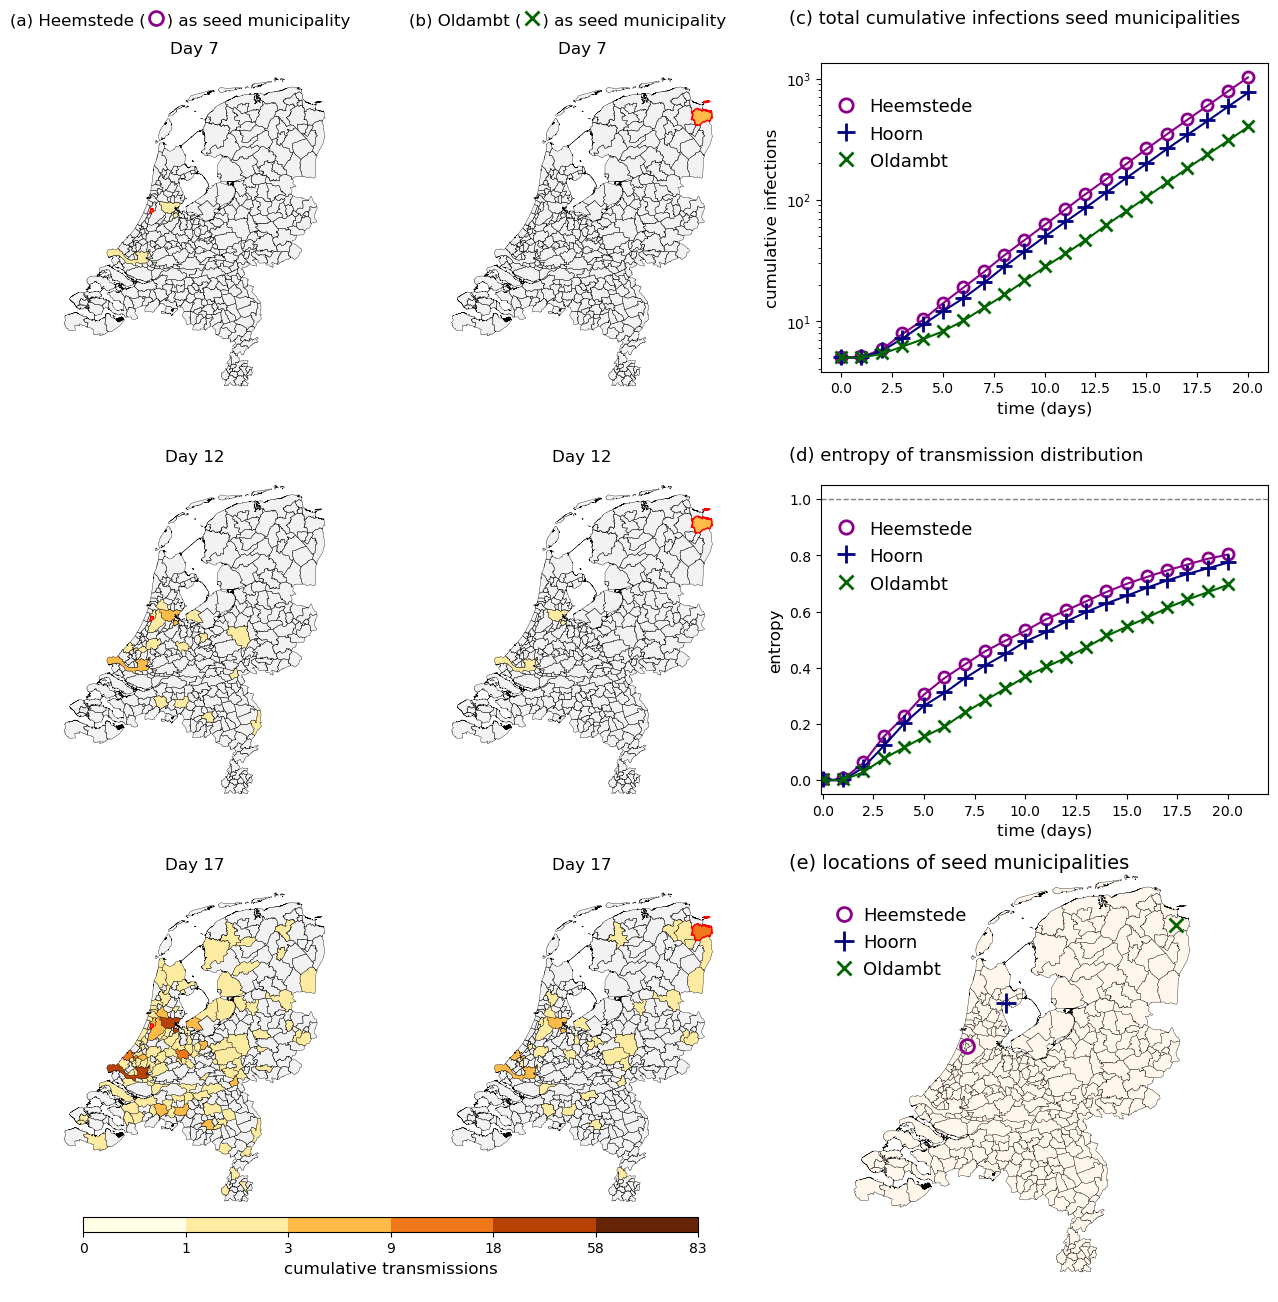

In [9]:
import os
os.makedirs('figures', exist_ok=True)

fig, axs = plt.subplots(3, 3, figsize=(15, 15))
fontsize = 12

gem1 = "Heemstede"
gem2 = "Oldambt"
loc1 = np.where(UniLocs == gem1)[0][0]
loc2 = np.where(UniLocs == gem2)[0][0]

# infected_seeds has shape (3, 504, 355) in order munis=[218, 126, 148]
loc1_idx = list(munis).index(loc1)
loc2_idx = list(munis).index(loc2)
infected_31 = infected_seeds[loc1_idx]  # Heemstede: (504, 355)
infected_32 = infected_seeds[loc2_idx]  # Oldambt:   (504, 355)

bounds, norm = create_spatial_7plots3_linear(
    infected_31, None, " ", "transmissions",
    target_municipality=gem1, cb_width=0.6,
    axobj=axs, axidx=[(0, 0), (1, 0), (2, 0)], fig=fig
)
axs[0, 0].annotate(f"(a) {gem1} (    ) as seed municipality",
                   xy=(0.45, 1.1), xycoords='axes fraction',
                   ha='center', va='bottom', fontsize=fontsize)

create_spatial_7plots3_linear(
    infected_32, None, " ", "transmissions",
    target_municipality=gem2, bounds=bounds, cb_width=0.6,
    axobj=axs, axidx=[(0, 1), (1, 1), (2, 1)], fig=fig
)
axs[0, 1].annotate(f"(b) {gem2} (    ) as seed municipality",
                   xy=(0.45, 1.1), xycoords='axes fraction',
                   ha='center', va='bottom', fontsize=fontsize)

### GRAPHS
fontsize = 14

# --- right column: cumulative infections ---
for _, data, name, color, marker in series_data2_sorted:
    if name != "Molenlanden":
        axs[0, 2].plot(data * 1.015, label=name, c=color, marker=marker,
                       linestyle='none', markersize=8, markeredgewidth=2, markerfacecolor='none')
        axs[0, 2].plot(data, c=color, linestyle='-')

axs[0, 2].set_xlabel('time (days)', fontsize=12)
axs[0, 2].set_ylabel('cumulative infections', fontsize=12)
axs[0, 2].set_yscale('log')
axs[0, 2].set_title("(c) total cumulative infections seed municipalities",
                    loc='left', x=-0.07, y=+1.1, fontsize=fontsize - 1)

# --- right column: entropy ---
for _, data, name, color, marker in series_data1_sorted:
    if name != "Molenlanden":
        axs[1, 2].plot(data + 0.003, label=name, c=color, marker=marker,
                       linestyle='none', markersize=8, markeredgewidth=2, markerfacecolor='none')
        axs[1, 2].plot(data, c=color, linestyle='-')

axs[1, 2].set_xlabel('time (days)', fontsize=12)
axs[1, 2].set_ylabel('entropy', fontsize=12)
axs[1, 2].set_title("(d) entropy of transmission distribution",
                    loc='left', x=-0.07, y=+1.055, fontsize=fontsize - 1)

# --- right column: map ---
mapdf = gpd.read_file('data/shapefile/gemeente_2019_v3.shp')
mapdf = mapdf[mapdf["H2O"] == "NEE"]
mapdf.sort_values("GM_NAAM", inplace=True)
mapdf = mapdf.reset_index(drop=True)
mapdf.insert(0, 'DATA', np.zeros(355))
mapdf.plot(ax=axs[2, 2], column='DATA', cmap='OrRd', edgecolor='black', linewidth=0.25)
plt.axis('off')

names = []
colorss = []
markerss = []
for _, data, name, color, marker in series_data1_sorted:
    geom = mapdf[mapdf['GM_NAAM'] == name].geometry
    centroid = geom.centroid.iloc[0]
    axs[2, 2].plot(centroid.x, centroid.y, marker=marker, color=color,
                   markersize=10, markeredgewidth=2, zorder=3, markerfacecolor='none')
    names.append(name)
    colorss.append(color)
    markerss.append(marker)

axs[2, 2].axis('off')

legend_elements = [
    Line2D([0], [0], marker=markerss[i], color=colorss[i], label=names[i],
           markersize=10, markeredgewidth=2, linestyle="None", markerfacecolor='none')
    for i in range(len(series_data1_sorted))
]

handles, labels = axs[0, 2].get_legend_handles_labels()
axs[0, 2].legend(handles, labels, frameon=False, bbox_to_anchor=(0, 0.94), loc='upper left',
                 handlelength=1, handleheight=1, markerscale=1.2, fontsize=fontsize - 1)
axs[1, 2].legend(handles, labels, frameon=False, bbox_to_anchor=(0, 0.94), loc='upper left',
                 handlelength=1, handleheight=1, markerscale=1.2, fontsize=fontsize - 1)

fig.subplots_adjust(hspace=0.2, wspace=0)

shrink = 0.91
for i in range(1):
    ax = axs[i, 2]
    pos = ax.get_position()
    ax.set_position([pos.x0 + 0.03, pos.y0 + 0.02,
                     pos.x1 - pos.x0 + 0.04, (pos.y1 - pos.y0) * shrink])

for i in range(1, 2):
    ax = axs[i, 2]
    pos = ax.get_position()
    ax.set_position([pos.x0 + 0.03, pos.y0 + 0.01,
                     pos.x1 - pos.x0 + 0.04, (pos.y1 - pos.y0) * shrink])

for i in range(2, 3):
    ax = axs[i, 2]
    pos = ax.get_position()
    ax.set_position([pos.x0, pos.y0 - 0.05,
                     pos.x1 - pos.x0 + 0.07, pos.y1 - pos.y0 + 0.065])

axs[1, 2].hlines(y=1, xmin=-0.1, xmax=25, color='grey', linestyle='--', linewidth=1)
axs[1, 2].set_xlim(-0.1, 22)
axs[2, 2].legend(handles=legend_elements, loc="upper left", frameon=False,
                 bbox_to_anchor=(-0.075, 0.92), fontsize=fontsize - 1,
                 handletextpad=0.1, markerscale=1)
axs[2, 2].set_title("(e) locations of seed municipalities",
                    loc='left', x=-0.13, y=0.95, fontsize=fontsize)

axs[0, 0].plot(0.366, 1.1298, marker=markerss[0], color=colorss[0], markersize=10,
               markeredgewidth=2, zorder=3, markerfacecolor='none',
               transform=axs[0, 0].transAxes, clip_on=False)
axs[0, 1].plot(0.325, 1.1298, marker=markerss[2], color=colorss[2], markersize=10,
               markeredgewidth=2, zorder=3, markerfacecolor='none',
               transform=axs[0, 1].transAxes, clip_on=False)

cmap = plt.get_cmap('YlOrBr')
cb_ax = fig.add_axes([0.18, 0.1, 0.41, 0.01])
cb = matplotlib.colorbar.ColorbarBase(cb_ax, cmap=cmap, norm=norm,
                                      spacing='uniform', ticks=bounds, boundaries=bounds,
                                      format='%1i', orientation='horizontal')
cb.set_label("cumulative transmissions", fontsize=12)

plt.savefig('figures/fig2.pdf', bbox_inches='tight')
plt.show()